# Notebook 04: Patient Engagement Segmentation — HealthFirst Australia

This notebook applies an **RFV framework** (Recency, Frequency, Value) adapted for healthcare
to segment the HealthFirst Australia patient population into seven clinically meaningful groups.
Segments inform personalised care coordination, re-engagement campaigns, and revenue strategy.

| Dimension | Healthcare Interpretation |
|-----------|---------------------------|
| **R — Recency** | Days since last appointment (fewer days = more engaged) |
| **F — Frequency** | Total appointments attended |
| **V — Value** | Total amount billed across all appointments |

**Author:** HealthFirst Analytics Team  
**Date:** April 2026  
**Data source:** `data/cleaned/`  
**Outputs:** `data/processed/` and `reports/`

---
## 1. Imports & Configuration

In [3]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Paths ───────────────────────────────────────────────────────────────────
DATA_CLEAN  = '../data/cleaned/'
DATA_PROC   = '../data/processed/'
REPORTS_DIR = '../reports/'

for d in [DATA_PROC, REPORTS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Plot style ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
BRAND_BLUE   = '#1F4E79'
BRAND_ORANGE = '#C55A11'
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.float_format', '{:,.2f}'.format)

# Segment colour palette
SEG_COLOURS = {
    'Active & Engaged':       '#1A7340',
    'Chronic Care Patient':   '#2E86AB',
    'New Patient':            '#5DADE2',
    'Preventive Only':        '#F6AE2D',
    'At Risk of Lapsing':     '#E67E22',
    'Disengaged':             '#95A5A6',
    'High Value Occasional':  '#8E44AD',
}

print('Environment ready.')

Environment ready.


---
## 2. Load Cleaned Data

In [5]:
patients     = pd.read_csv(DATA_CLEAN + 'patients.csv')
appointments = pd.read_csv(
    DATA_CLEAN + 'appointments.csv',
    parse_dates=['appointment_date']
)
surveys = pd.read_csv(
    DATA_CLEAN + 'satisfaction_surveys.csv',
    parse_dates=['survey_date']
)

print(f'Patients:     {patients.shape[0]:,} rows × {patients.shape[1]} cols')
print(f'Appointments: {appointments.shape[0]:,} rows × {appointments.shape[1]} cols')
print(f'Surveys:      {surveys.shape[0]:,} rows × {surveys.shape[1]} cols')

# Snapshot date for recency calculation
SNAPSHOT = appointments['appointment_date'].max()
print(f'\nSnapshot date (recency anchor): {SNAPSHOT.date()}')

Patients:     3,000 rows × 20 cols
Appointments: 20,000 rows × 16 cols
Surveys:      3,894 rows × 12 cols

Snapshot date (recency anchor): 2025-12-28


---
## 3. Calculate Raw R, F, V per Patient

In [7]:
# Consider only attended / completed appointments for RFV scoring
# (no-shows do not constitute meaningful engagement)
completed = appointments[
    ~appointments['status']
    .fillna('')
    .str.lower()
    .str.contains(r'no.show|no show|dna|cancelled|canceled')
].copy()

rfv_raw = (
    completed
    .groupby('patient_id')
    .agg(
        last_appointment  = ('appointment_date', 'max'),
        first_appointment = ('appointment_date', 'min'),
        frequency         = ('appointment_id',   'count'),
        value             = ('billed_amount',    'sum'),
        avg_wait_days     = ('wait_days',        'mean'),
    )
    .reset_index()
)

rfv_raw['recency']                  = (SNAPSHOT - rfv_raw['last_appointment']).dt.days
rfv_raw['days_since_first_appt']    = (SNAPSHOT - rfv_raw['first_appointment']).dt.days

print(f'Patients with appointment history: {len(rfv_raw):,}')
print()
rfv_raw[['recency', 'frequency', 'value', 'avg_wait_days']].describe()

Patients with appointment history: 2,982



,recency,frequency,value,avg_wait_days
count,"2,982.00","2,982.00","2,982.00","2,982.00"
mean,154.06,4.67,518.83,21.34
std,135.70,2.13,389.95,8.50
min,0.00,1.00,0.00,0.00
25%,51.00,3.00,241.71,16.00
50%,113.00,4.00,421.13,20.33
75%,215.00,6.00,682.09,25.36
max,721.00,14.00,"2,540.41",70.00


---
## 4. Score R, F, V on 1–4 Scale (Quartile-Based)

- **R score**: Scored *inversely* — shorter recency (more recent) gets score 4
- **F score**: Higher frequency = higher score
- **V score**: Higher total billed = higher score

In [9]:
def quartile_score(series: pd.Series, ascending: bool = True) -> pd.Series:
    """
    Assign a 1–4 quartile score.
    ascending=True  → higher value → higher score (used for F and V)
    ascending=False → lower value  → higher score (used for R: fewer days = more recent)
    """
    labels = [1, 2, 3, 4] if ascending else [4, 3, 2, 1]
    return pd.qcut(series, q=4, labels=labels, duplicates='drop').astype(int)

rfv = rfv_raw.copy()
rfv['R'] = quartile_score(rfv['recency'],   ascending=False)  # lower days = score 4
rfv['F'] = quartile_score(rfv['frequency'], ascending=True)
rfv['V'] = quartile_score(rfv['value'],     ascending=True)

rfv['RFV_avg'] = (rfv['R'] + rfv['F'] + rfv['V']) / 3

print('RFV score distributions (1 = lowest quartile, 4 = highest):')
for dim in ['R', 'F', 'V']:
    print(f'  {dim}: {dict(rfv[dim].value_counts().sort_index())}')

rfv.head(5)

RFV score distributions (1 = lowest quartile, 4 = highest):
  R: {1: 745, 2: 742, 3: 746, 4: 749}
  F: {1: 935, 2: 611, 3: 881, 4: 555}
  V: {1: 746, 2: 745, 3: 745, 4: 746}


,patient_id,last_appointment,first_appointment,frequency,value,avg_wait_days,recency,days_since_first_appt,R,F,V,RFV_avg
0,1,2025-06-07,2024-03-06,7,"1,176.76",22.57,204,662,2,4,4,3.33
1,2,2025-11-07,2024-02-08,4,280.70,17.00,51,689,4,2,2,2.67
2,3,2025-09-14,2024-09-23,2,"1,019.00",20.00,105,461,3,1,4,2.67
3,4,2025-11-28,2024-08-31,6,"1,664.97",28.17,30,484,4,3,4,3.67
4,5,2025-02-11,2024-01-07,5,"1,488.50",22.80,320,721,1,3,4,2.67


---
## 5. Merge Patient Demographics & Assign Segments

Segmentation rules are applied in priority order.
Each patient is assigned to exactly one segment.

In [11]:
# Merge RFV scores with patient demographics
rfv = rfv.merge(
    patients[[
        'patient_id', 'full_name', 'gender', 'age', 'age_group',
        'state', 'insurance_type', 'health_fund',
        'chronic_conditions', 'referral_source',
        'churn_flag', 'total_appointments', 'total_billed'
    ]],
    on='patient_id', how='left'
)

# Flag: patient has at least one chronic condition recorded
rfv['has_chronic'] = (
    rfv['chronic_conditions']
    .fillna('None')
    .str.strip()
    .ne('None')
)

print(f'Combined RFV + demographics: {rfv.shape}')

Combined RFV + demographics: (2982, 25)


In [12]:
def assign_segment(row) -> str:
    """
    Assign a healthcare-specific engagement segment using RFV scores
    and clinical attributes. Rules applied in priority order.
    """
    r = row['R']
    f = row['F']
    v = row['V']
    total_appts          = row['total_appointments']
    days_since_first     = row['days_since_first_appt']
    avg_wait             = row['avg_wait_days']
    has_chronic          = row['has_chronic']

    # 1. Active & Engaged — high across all three dimensions
    if r >= 3 and f >= 3 and v >= 3:
        return 'Active & Engaged'

    # 2. Chronic Care Patient — frequent visitor with chronic conditions
    if f >= 3 and has_chronic:
        return 'Chronic Care Patient'

    # 3. New Patient — early in their healthcare journey
    if total_appts <= 2 and days_since_first < 180:
        return 'New Patient'

    # 4. Preventive Only — low frequency, short waits (only comes for check-ups)
    if f <= 2 and avg_wait < 20:
        return 'Preventive Only'

    # 5. At Risk of Lapsing — was regular but recency has dropped off
    if r <= 2 and f >= 2:
        return 'At Risk of Lapsing'

    # 6. High Value Occasional — high spend, infrequent visits
    if v >= 3 and f <= 2:
        return 'High Value Occasional'

    # 7. Disengaged — low recency and low frequency
    if r <= 2 and f <= 2:
        return 'Disengaged'

    # Fallback — catches remaining edge cases
    return 'Disengaged'

rfv['segment'] = rfv.apply(assign_segment, axis=1)

print('Patient count per segment:')
print(rfv['segment'].value_counts().to_string())

Patient count per segment:
segment
Preventive Only          730
Active & Engaged         681
Disengaged               501
At Risk of Lapsing       423
Chronic Care Patient     401
High Value Occasional    175
New Patient               71


---
## 6. Segment Profile Table

In [14]:
# Merge survey scores for satisfaction analysis
avg_satisfaction = (
    surveys
    .groupby('patient_id')
    .agg(avg_satisfaction=('overall_score', 'mean'))
    .reset_index()
)

rfv_full = rfv.merge(avg_satisfaction, on='patient_id', how='left')

seg_profile = (
    rfv_full
    .groupby('segment')
    .agg(
        patient_count    = ('patient_id',       'count'),
        avg_wait         = ('avg_wait_days',     'mean'),
        avg_billed       = ('total_billed',      'mean'),
        total_revenue    = ('total_billed',      'sum'),
        churn_rate       = ('churn_flag',        'mean'),
        avg_satisfaction = ('avg_satisfaction',  'mean'),
        avg_R            = ('R',                 'mean'),
        avg_F            = ('F',                 'mean'),
        avg_V            = ('V',                 'mean'),
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

seg_profile['revenue_share_pct'] = (
    seg_profile['total_revenue'] / seg_profile['total_revenue'].sum() * 100
)
seg_profile['churn_rate_pct'] = seg_profile['churn_rate'] * 100

print('SEGMENT PROFILE — HealthFirst Australia')
print('=' * 90)
display_cols = [
    'segment', 'patient_count', 'avg_wait', 'avg_billed',
    'churn_rate_pct', 'avg_satisfaction', 'revenue_share_pct'
]
print(seg_profile[display_cols].to_string(index=False))

SEGMENT PROFILE — HealthFirst Australia
              segment  patient_count  avg_wait  avg_billed  churn_rate_pct  avg_satisfaction  revenue_share_pct
     Active & Engaged            681     21.94      867.55           19.09              6.61              38.19
   At Risk of Lapsing            423     23.31      596.88           20.09              6.52              16.32
 Chronic Care Patient            401     20.26      590.61           20.45              6.69              15.31
      Preventive Only            730     14.09      291.14           22.19              6.99              13.74
           Disengaged            501     27.43      249.49           23.15              6.69               8.08
High Value Occasional            175     29.80      674.56           15.43              6.62               7.63
          New Patient             71     20.76      161.69           16.90              7.13               0.74


---
## 7. Merge Churn Probability from Notebook 03

In [16]:
# Load churn scores produced by Notebook 03 (if available)
churn_scored_path = DATA_PROC + 'patients_churn_scored.csv'
try:
    churn_scored = pd.read_csv(churn_scored_path)
    rfv_full = rfv_full.merge(
        churn_scored[['patient_id', 'churn_probability']],
        on='patient_id', how='left'
    )
    print(f'Churn scores merged: {churn_scored.shape[0]:,} records')

    # Segment-level average churn probability
    seg_churn_prob = (
        rfv_full
        .groupby('segment')['churn_probability']
        .mean()
        .reset_index()
        .rename(columns={'churn_probability': 'avg_churn_prob'})
    )
    seg_profile = seg_profile.merge(seg_churn_prob, on='segment', how='left')
    print('\nAverage churn probability by segment:')
    print(
        seg_profile[['segment', 'avg_churn_prob']]
        .sort_values('avg_churn_prob', ascending=False)
        .to_string(index=False)
    )
except FileNotFoundError:
    print(f'Churn scored file not found at {churn_scored_path}.')
    print('Run Notebook 03 first to generate churn probabilities.')
    seg_profile['avg_churn_prob'] = np.nan

Churn scores merged: 3,000 records

Average churn probability by segment:
              segment  avg_churn_prob
          New Patient            0.23
           Disengaged            0.23
      Preventive Only            0.22
   At Risk of Lapsing            0.20
     Active & Engaged            0.19
 Chronic Care Patient            0.19
High Value Occasional            0.17


---
## 8. Visualisations

Three charts: segment size, revenue contribution, and average satisfaction.

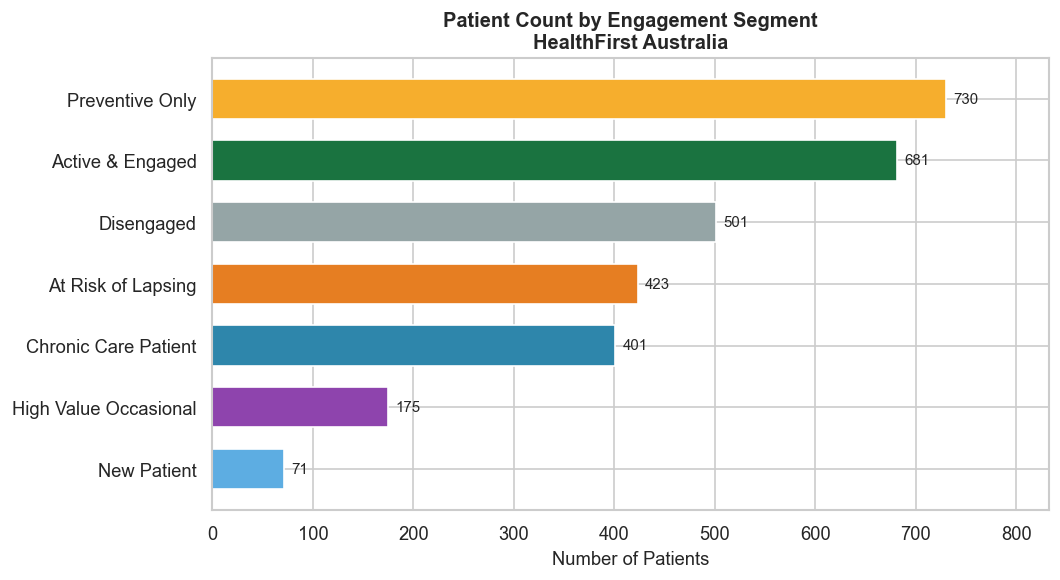

Saved: ../reports/patient_segments.png


In [18]:
# ── Chart 1: Patient Count by Segment (horizontal bar) ────────────────────────

sc = seg_profile.sort_values('patient_count', ascending=True)
bar_colours = [SEG_COLOURS.get(s, '#AAAAAA') for s in sc['segment']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(sc['segment'], sc['patient_count'], color=bar_colours,
               edgecolor='white', height=0.65)

for bar, val in zip(bars, sc['patient_count']):
    ax.text(
        bar.get_width() + sc['patient_count'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}', va='center', fontsize=9
    )

ax.set_xlabel('Number of Patients', fontsize=11)
ax.set_title(
    'Patient Count by Engagement Segment\nHealthFirst Australia',
    fontsize=12, fontweight='bold'
)
ax.set_xlim([0, sc['patient_count'].max() * 1.14])

plt.tight_layout()
seg_bar_path = REPORTS_DIR + 'patient_segments.png'
plt.savefig(seg_bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {seg_bar_path}')

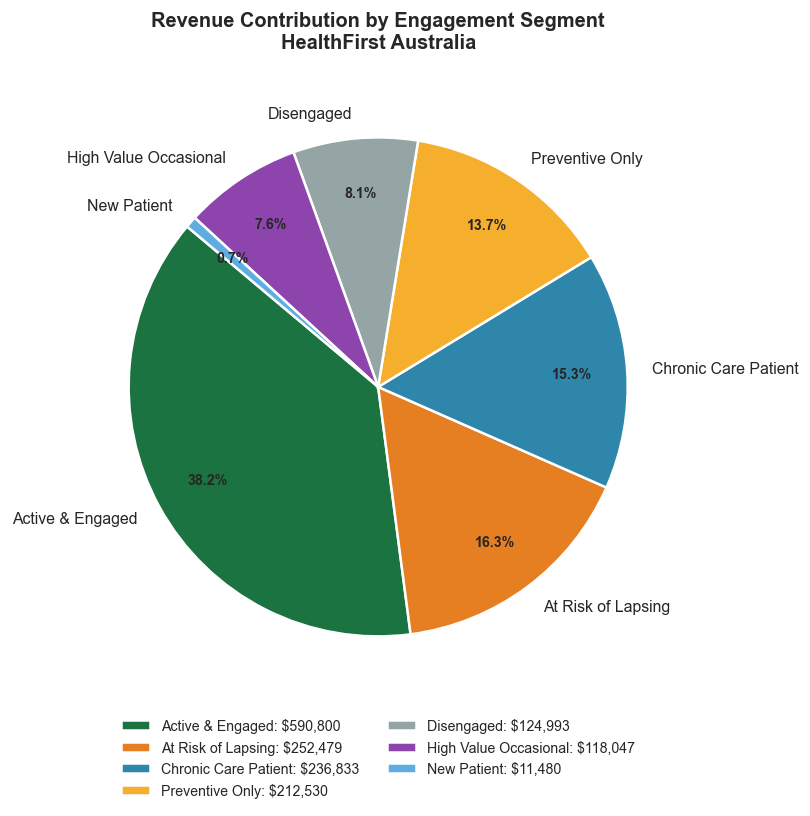

Saved: ../reports/segment_revenue_share.png


In [19]:
# ── Chart 2: Revenue Contribution by Segment (pie chart) ──────────────────────

pie_order = seg_profile.sort_values('total_revenue', ascending=False)
pie_colours = [SEG_COLOURS.get(s, '#AAAAAA') for s in pie_order['segment']]

fig, ax = plt.subplots(figsize=(8, 7))
wedges, texts, autotexts = ax.pie(
    pie_order['total_revenue'],
    labels=pie_order['segment'],
    colors=pie_colours,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.78,
    textprops={'fontsize': 9.5},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(8.5)
    at.set_fontweight('bold')

ax.set_title(
    'Revenue Contribution by Engagement Segment\nHealthFirst Australia',
    fontsize=12, fontweight='bold', pad=16
)

# Legend with dollar values
legend_labels = [
    f'{row.segment}: ${row.total_revenue:,.0f}'
    for _, row in pie_order.iterrows()
]
ax.legend(
    wedges, legend_labels,
    loc='lower center', bbox_to_anchor=(0.5, -0.18),
    fontsize=8.5, frameon=False, ncol=2
)

plt.tight_layout()
rev_pie_path = REPORTS_DIR + 'segment_revenue_share.png'
plt.savefig(rev_pie_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {rev_pie_path}')

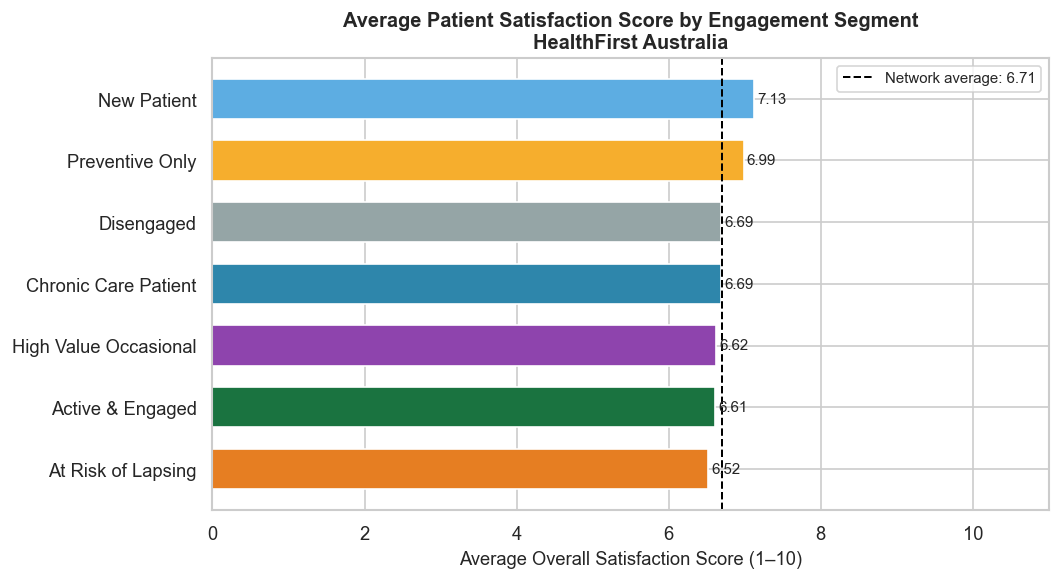

Saved: ../reports/segment_satisfaction.png


In [20]:
# ── Chart 3: Average Satisfaction Score by Segment (bar chart) ────────────────

sat_order = seg_profile.sort_values('avg_satisfaction', ascending=True).dropna(subset=['avg_satisfaction'])
sat_colours = [SEG_COLOURS.get(s, '#AAAAAA') for s in sat_order['segment']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    sat_order['segment'],
    sat_order['avg_satisfaction'],
    color=sat_colours,
    edgecolor='white',
    height=0.65
)

# Overall average satisfaction reference line
overall_sat = rfv_full['avg_satisfaction'].mean()
ax.axvline(
    overall_sat, color='black', linestyle='--', lw=1.2,
    label=f'Network average: {overall_sat:.2f}'
)

for bar, val in zip(bars, sat_order['avg_satisfaction']):
    ax.text(
        bar.get_width() + 0.04,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}', va='center', fontsize=9
    )

ax.set_xlabel('Average Overall Satisfaction Score (1–10)', fontsize=11)
ax.set_title(
    'Average Patient Satisfaction Score by Engagement Segment\nHealthFirst Australia',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=9)
ax.set_xlim([0, 11])

plt.tight_layout()
sat_path = REPORTS_DIR + 'segment_satisfaction.png'
plt.savefig(sat_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {sat_path}')

---
## 9. Action Playbook by Segment

In [22]:
playbook = pd.DataFrame([
    {
        'Segment':         'Active & Engaged',
        'Priority':        'Retain & Reward',
        'Recommended Actions': (
            'Loyalty reward program; health screening offers; '
            'invite to HealthFirst member events; satisfaction surveys'
        ),
        'KPI to Watch':    'Retention rate; NPS score; referral count',
    },
    {
        'Segment':         'Chronic Care Patient',
        'Priority':        'Care Coordination',
        'Recommended Actions': (
            'Enrol in annual care plans (item 721); '
            'app-based medication and appointment reminders; '
            'allied health team referrals; care coordinator outreach'
        ),
        'KPI to Watch':    'Appointment adherence; care plan completion rate; readmission rate',
    },
    {
        'Segment':         'New Patient',
        'Priority':        'Activate & Onboard',
        'Recommended Actions': (
            'Welcome call within 7 days of first visit; '
            'follow-up appointment reminder; '
            'send HealthFirst patient guide; survey after first appointment'
        ),
        'KPI to Watch':    'Day-90 repeat visit rate; onboarding completion',
    },
    {
        'Segment':         'Preventive Only',
        'Priority':        'Educate & Upsell',
        'Recommended Actions': (
            'Health screening packages (skin checks, diabetes screening); '
            'chronic disease education materials; '
            'offer telehealth options for convenience'
        ),
        'KPI to Watch':    'Screening uptake; frequency uplift; telehealth adoption',
    },
    {
        'Segment':         'At Risk of Lapsing',
        'Priority':        'Re-Engage Urgently',
        'Recommended Actions': (
            'Personalised re-engagement letter from treating GP; '
            'GP check-in call from reception; '
            'offer flexible booking slots and telehealth alternatives'
        ),
        'KPI to Watch':    'Reactivation rate within 60 days; churn probability trend',
    },
    {
        'Segment':         'Disengaged',
        'Priority':        'Low-Cost Win-Back',
        'Recommended Actions': (
            'Low-cost win-back letter highlighting new services; '
            'seasonal health reminder (flu season, summer skin checks); '
            'accept graceful exit if no response after two attempts'
        ),
        'KPI to Watch':    'Response rate; cost per reactivation',
    },
    {
        'Segment':         'High Value Occasional',
        'Priority':        'Premium Service Offer',
        'Recommended Actions': (
            'Premium service offer (concierge booking, priority slots); '
            'specialist fast-track referrals; '
            'personal health management plan; VIP satisfaction outreach'
        ),
        'KPI to Watch':    'Visit frequency; average billing per visit; NPS',
    },
])

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 200)

print('HEALTHFIRST AUSTRALIA — SEGMENT ACTION PLAYBOOK')
print('=' * 100)
print(playbook.to_string(index=False))

HEALTHFIRST AUSTRALIA — SEGMENT ACTION PLAYBOOK
              Segment              Priority                                                                                                                                                   Recommended Actions                                                       KPI to Watch
     Active & Engaged       Retain & Reward                                                            Loyalty reward program; health screening offers; invite to HealthFirst member events; satisfaction surveys                          Retention rate; NPS score; referral count
 Chronic Care Patient     Care Coordination                        Enrol in annual care plans (item 721); app-based medication and appointment reminders; allied health team referrals; care coordinator outreach Appointment adherence; care plan completion rate; readmission rate
          New Patient    Activate & Onboard                             Welcome call within 7 days of first visit; follow

---
## 10. Export Patient Segments

In [24]:
export_cols = [
    'patient_id', 'full_name', 'gender', 'age', 'age_group',
    'state', 'insurance_type', 'health_fund',
    'chronic_conditions', 'has_chronic',
    'recency', 'frequency', 'value',
    'R', 'F', 'V', 'RFV_avg',
    'avg_wait_days', 'total_appointments', 'total_billed',
    'churn_flag', 'segment'
]

# Add churn_probability if it was merged
if 'churn_probability' in rfv_full.columns:
    export_cols.append('churn_probability')
if 'avg_satisfaction' in rfv_full.columns:
    export_cols.append('avg_satisfaction')

export_df = rfv_full[[c for c in export_cols if c in rfv_full.columns]].copy()

seg_path = DATA_PROC + 'patient_segments.csv'
export_df.to_csv(seg_path, index=False)

print(f'Saved: {seg_path}')
print(f'Rows: {len(export_df):,}  |  Columns: {export_df.shape[1]}')
print()
print('Final segment summary:')
print(
    export_df
    .groupby('segment')
    .agg(
        patients      = ('patient_id', 'count'),
        avg_billed    = ('total_billed', 'mean'),
        total_revenue = ('total_billed', 'sum'),
    )
    .assign(revenue_share_pct=lambda df: df['total_revenue'] / df['total_revenue'].sum() * 100)
    .sort_values('total_revenue', ascending=False)
    .reset_index()
    .to_string(index=False)
)

Saved: ../data/processed/patient_segments.csv
Rows: 2,982  |  Columns: 24

Final segment summary:
              segment  patients  avg_billed  total_revenue  revenue_share_pct
     Active & Engaged       681      867.55     590,799.78              38.19
   At Risk of Lapsing       423      596.88     252,478.56              16.32
 Chronic Care Patient       401      590.61     236,833.37              15.31
      Preventive Only       730      291.14     212,529.76              13.74
           Disengaged       501      249.49     124,992.99               8.08
High Value Occasional       175      674.56     118,047.47               7.63
          New Patient        71      161.69      11,480.14               0.74


---
## Summary

### Segments defined

| Segment | Typical Profile | Strategic Priority |
|---------|-----------------|--------------------|
| Active & Engaged | Recent, frequent, high-billing | Retain & reward |
| Chronic Care Patient | Frequent visits, ongoing conditions | Care coordination |
| New Patient | ≤2 appointments, joined recently | Onboarding & activation |
| Preventive Only | Infrequent, short waits — checkup visits | Educate & upsell |
| At Risk of Lapsing | Regular history but quiet recently | Urgent re-engagement |
| Disengaged | Low recency and low frequency | Low-cost win-back |
| High Value Occasional | High spend, infrequent visits | Premium service offer |

### Outputs produced

| File | Description |
|------|-------------|
| `data/processed/patient_segments.csv` | All patients with RFV scores and segment labels |
| `reports/patient_segments.png` | Horizontal bar chart — patient count per segment |
| `reports/segment_revenue_share.png` | Pie chart — revenue contribution by segment |
| `reports/segment_satisfaction.png` | Bar chart — average satisfaction score by segment |

### Next steps
- Load `patient_segments.csv` into the CRM or patient management system for targeted outreach.
- Monitor segment migration over quarterly snapshots — patients moving from *Active & Engaged* to *At Risk of Lapsing* signal early intervention opportunities.
- Combine segment labels with churn probability scores from **Notebook 03** for a unified risk-and-engagement dashboard.